In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
with open('all_toxicity_results/experimental_outputs/generalization_results_non_linear.json', 'r') as f:
    outs = json.load(f)

In [3]:
rows = []
for entry in outs:
    # Metadata
    model = entry['model']
    probe = entry['probe']
    layer = entry['layer']
    family = 'Qwen' if 'Qwen' in model else 'Gemma'
    
    # Iterate through training datasets (keys in the entry that aren't metadata)
    metadata_keys = {'model', 'probe', 'layer', 'oracle', 'noperiod'}
    train_sets = [k for k in entry.keys() if k not in metadata_keys]
    
    for t_set in train_sets:
        eval_dict = entry[t_set]
        for e_set, acc in eval_dict.items():
            rows.append({
                'Model': model,
                'Family': family,
                'Probe': probe,
                'Layer_Idx': layer,
                'Train_Set': t_set,
                'Eval_Set': e_set,
                'Accuracy': acc,
                'Is_OOD': t_set != e_set  # Out-of-Distribution flag
            })

df = pd.DataFrame(rows)

In [4]:
df.head()

,Model,Family,Probe,Layer_Idx,Train_Set,Eval_Set,Accuracy,Is_OOD
0,Qwen3-4B,Qwen,LRProbe,6,code-review-dataset-larger,cumstrudel_train_comments_balanced,0.601190,True
1,Qwen3-4B,Qwen,LRProbe,6,code-review-dataset-larger,hatecheck_validation_balanced,0.552632,True
2,Qwen3-4B,Qwen,LRProbe,6,code-review-dataset-larger+neg-code-review-larger,cumstrudel_train_comments_balanced,0.523810,True
3,Qwen3-4B,Qwen,LRProbe,6,code-review-dataset-larger+neg-code-review-larger,hatecheck_validation_balanced,0.511278,True
4,Qwen3-4B,Qwen,LRProbe,6,gitter_ethereum-labeled-larger,cumstrudel_train_comments_balanced,0.648810,True


In [5]:
def map_layers(group):
    unique_layers = sorted(group['Layer_Idx'].unique())
    mapping = {idx: name for idx, name in zip(unique_layers, ['a', 'b1', 'b2', 'c'])}
    group['Layer_Group'] = group['Layer_Idx'].map(mapping)
    return group

df = df.groupby('Model', group_keys=False).apply(map_layers)

/var/folders/l_/qy6xpxn531ngvxwsvs64x62h0000gn/T/ipykernel_7817/3730468313.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Model', group_keys=False).apply(map_layers)


## Non-Linear vs Linear Delta Heatmap

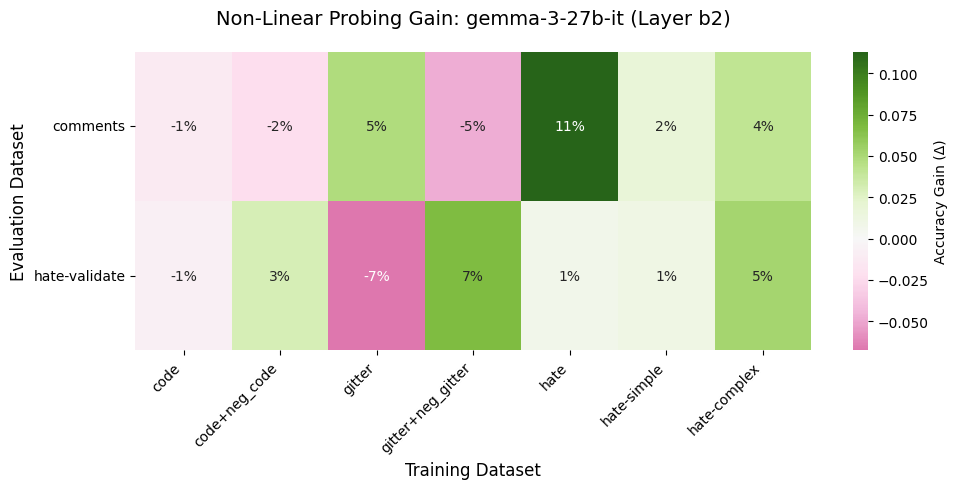

In [57]:
# 1. Define the mapping from your JSON keys to your paper labels
label_mapping = {
    "code-review-dataset-larger": "code",
    "code-review-dataset-larger+neg-code-review-larger": "code+neg_code",
    "gitter_ethereum-labeled-larger": "gitter",
    "gitter_ethereum-labeled-larger+neg-gitter-ethereum-labeled-larger": "gitter+neg_gitter",
    "hatecheck_balanced": "hate",
    "hatecheck_simple_balanced": "hate-simple",
    "hatecheck_complex_balanced": "hate-complex",
    "cumstrudel_train_comments_balanced": "comments",
    "hatecheck_validation_balanced": "hate-validate"
}

# 2. These lists define the visual order of your heatmap
labels_x = ["code", "code+neg_code", "gitter", "gitter+neg_gitter", "hate", "hate-simple", "hate-complex"]
labels_y = ["comments", "hate-validate"]

def plot_refined_delta_heatmap(df, model_name, layer_group):
    # Filter for the specific model and layer
    subset = df[(df['Model'] == model_name) & (df['Layer_Group'] == layer_group)].copy()
    
    # Map the long names to abbreviated labels
    subset['Train_Set'] = subset['Train_Set'].map(label_mapping)
    subset['Eval_Set'] = subset['Eval_Set'].map(label_mapping)
    
    # Create the grids for both probes
    lr_grid = subset[subset['Probe'] == 'LRProbe'].pivot(index='Eval_Set', columns='Train_Set', values='Accuracy')
    mlp_grid = subset[subset['Probe'] == 'NonLinearProbe'].pivot(index='Eval_Set', columns='Train_Set', values='Accuracy')
    
    # Reindex to ensure the order matches your paper's requirements
    lr_grid = lr_grid.reindex(index=labels_y, columns=labels_x)
    mlp_grid = mlp_grid.reindex(index=labels_y, columns=labels_x)
    
    # Calculate Delta: Δ = MLP - LR
    delta_grid = mlp_grid - lr_grid

    # Plotting
    plt.figure(figsize=(10, 5))
    ax = sns.heatmap(delta_grid, annot=True, fmt=".0%", cmap="PiYG", center=0, 
                     cbar_kws={'label': 'Accuracy Gain (Δ)'})
    
    # Set labels and title
    plt.title(f"Non-Linear Probing Gain: {model_name} (Layer {layer_group})", fontsize=14, pad=20)
    plt.xlabel("Training Dataset", fontsize=12)
    plt.ylabel("Evaluation Dataset", fontsize=12)

    # Apply rotations
    # X-axis: 45° rotation
    plt.xticks(rotation=45, ha='right')
    
    # Y-axis: 90° rotation (Vertical labels)
    plt.yticks(rotation=0, va='center')

    plt.tight_layout()
    plt.show()

# Run the plot
plot_refined_delta_heatmap(df, 'gemma-3-27b-it', 'b2')

## Layer-wise accuracy avg. over all models per Family

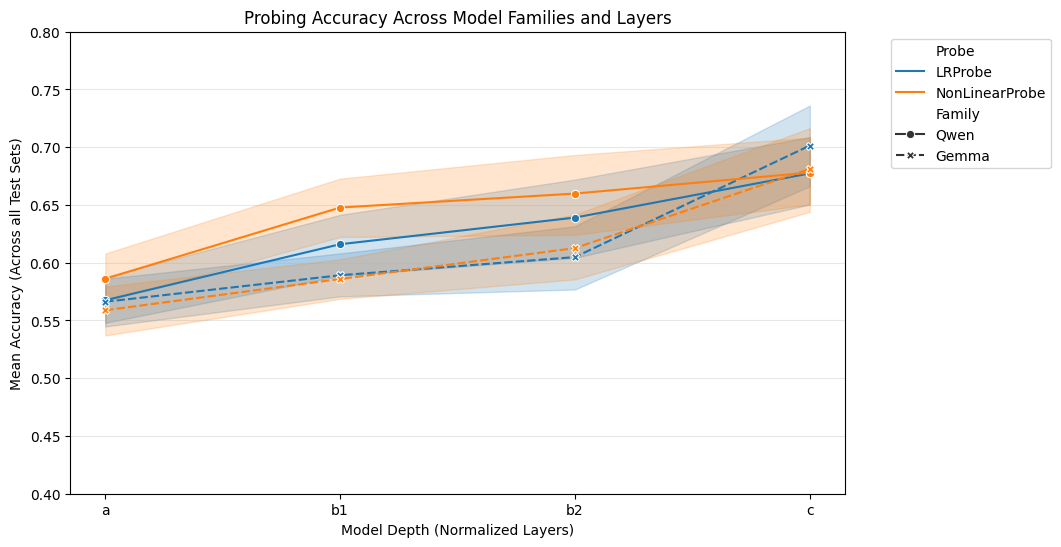

In [7]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Layer_Group', y='Accuracy', hue='Probe', style='Family', 
             markers=True, dashes=True, err_style="band")

plt.title("Probing Accuracy Across Model Families and Layers")
plt.ylabel("Mean Accuracy (Across all Test Sets)")
plt.xlabel("Model Depth (Normalized Layers)")
plt.ylim(0.4, 0.8) # Adjust based on your data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Generalization Scatter (Robustness)

In [8]:
# Aggregate data: In-Distribution vs Out-of-Distribution
agg_df = df.groupby(['Model', 'Probe', 'Is_OOD'])['Accuracy'].mean().unstack('Is_OOD').reset_index()
agg_df.columns = ['Model', 'Probe', 'In_Dist_Acc', 'OOD_Acc']

plt.figure(figsize=(8, 8))
sns.scatterplot(data=agg_df, x='In_Dist_Acc', y='OOD_Acc', hue='Probe', style='Probe', s=100)

# Add a 1:1 line (points above this line generalize better than they perform locally)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title("Generalization: In-Distribution vs. Out-of-Distribution")
plt.xlabel("Accuracy (Train Set == Eval Set)")
plt.ylabel("Accuracy (Train Set != Eval Set)")
plt.xlim(0.4, 0.9)
plt.ylim(0.4, 0.9)
plt.grid(True, alpha=0.2)
plt.show()

ValueError: Length mismatch: Expected axis has 3 elements, new values have 4 elements

In [59]:
from scipy.stats import wilcoxon

def run_significance_test(df):
    # 1. Pivot the data so LR and MLP accuracies are side-by-side for every 'pair'
    # A 'pair' = (Model + Layer + Train_Set + Eval_Set)
    pivot_df = df.pivot_table(
            index=['Model', 'Layer_Group', 'Train_Set', 'Eval_Set'], 
            columns='Probe', 
            values='Accuracy',
            aggfunc='mean'  # This resolves the ValueError
            ).dropna()

    lr_scores = pivot_df['LRProbe']
    mlp_scores = pivot_df['NonLinearProbe']

    # 2. Perform the Wilcoxon Signed-Rank Test
    # alternative='greater' tests the hypothesis that MLP > LR
    stat, p_value = wilcoxon(mlp_scores, lr_scores, alternative='greater')

    # 3. Calculate the Effect Size (Median Difference)
    median_diff = (mlp_scores - lr_scores).median()

    print("--- Statistical Analysis Results ---")
    print(f"Number of pairs tested (N): {len(pivot_df)}")
    print(f"Median Accuracy Improvement: {median_diff:.2%}")
    print(f"Wilcoxon Statistic: {stat}")
    print(f"p-value: {p_value:.4e}")

    if p_value < 0.05:
        print("Result: Statistically Significant (p < 0.05)")
    else:
        print("Result: Not Statistically Significant")
        
    return p_value, median_diff

# Run the test
p, med = run_significance_test(df)

--- Statistical Analysis Results ---
Number of pairs tested (N): 588
Median Accuracy Improvement: 0.75%
Wilcoxon Statistic: 95415.0
p-value: 3.3794e-05
Result: Statistically Significant (p < 0.05)
